<a href="https://colab.research.google.com/github/jonathanastudillo-lab/Ejercicio/blob/main/trabajo_unidad_3_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Unidad 3 - Machine Learning
## Algoritmos no supervisados: clustering con y sin PCA

**Carrera:** Ingeniería Civil Industrial  
**Asignatura:** Machine Learning  
**Profesor:** Franco Andrés Mansilla  

**Integrantes:**
- Jonathan Astudillo Vergara
- Gustavo Gutiérrez Díaz
- Mario Miño Farfán
- Robinson Sánchez Águila
- Leonel Tapia Araya

**Fecha:** 05.05.2026

---
# Introducción

En este trabajo se aplica aprendizaje no supervisado sobre la base de datos **House Prices**, utilizada previamente en las unidades 1 y 2. A diferencia de los trabajos anteriores, el objetivo principal no es predecir directamente el precio de venta de una vivienda, sino identificar agrupaciones o patrones naturales entre viviendas con características similares.

Para evitar sesgo en el análisis, la variable `SalePrice` se separa del conjunto de variables explicativas y no se utiliza durante el entrenamiento de los modelos de clustering. Posteriormente, esta variable se reincorpora solo para interpretar si los clusters obtenidos logran diferenciar viviendas de distinto nivel de precio.

El desarrollo considera dos bases de trabajo: una base transformada mediante One-Hot Encoding y normalización **sin PCA**, y otra base **con PCA**, donde se reduce la dimensionalidad conservando al menos el 90% de la varianza explicada. Luego, se comparan algoritmos basados en distancia y densidad, evaluando sus resultados mediante métricas internas de clustering.

---
# Punto 1. Preparación de datos

## 1.1 Carga de la base limpia obtenida en las unidades anteriores

Se utiliza la base trabajada en las unidades anteriores como punto de partida, manteniendo continuidad metodológica. Aunque esta base ya fue preparada previamente, aún conserva valores faltantes en algunas variables, por lo que se realiza una revisión complementaria antes de aplicar los algoritmos de clustering.

In [ ]:
# Importar librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Parámetros simples del trabajo
RANDOM_STATE = 42
TARGET = "SalePrice"

# Base limpia creada en la Unidad 1 y usada en la Unidad 2
url_limpia = "https://raw.githubusercontent.com/jonathanastudillo-lab/Ejercicio/main/house_prices_base_limpia_sumativo1.csv"

# Cargar base limpia
df_limpia = pd.read_csv(url_limpia)

print("Dimensión base limpia U1/U2:", df_limpia.shape)
df_limpia.head()

Dimensión base limpia U1/U2: (1460, 73)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450.0,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0.00,0,0.0,0,0,2,2008,WD,Normal,208500.0
1,20,RL,80.0,9600.0,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0.00,0,0.0,0,0,5,2007,WD,Normal,181500.0
2,60,RL,68.0,11250.0,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0.00,0,0.0,0,0,9,2008,WD,Normal,223500.0
3,70,RL,60.0,9550.0,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,261.05,0,0.0,0,0,2,2006,WD,Abnorml,140000.0
4,60,RL,84.0,14260.0,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0.00,0,0.0,0,0,12,2008,WD,Normal,250000.0


In [ ]:
# Revisión simple de la base limpia oficial

resumen_base = pd.DataFrame({
    "Indicador": [
        "Filas",
        "Columnas",
        "Nulos totales",
        "Columnas numéricas",
        "Columnas categóricas",
        "Contiene SalePrice",
        "Contiene Id"
    ],
    "Valor": [
        df_limpia.shape[0],
        df_limpia.shape[1],
        df_limpia.isna().sum().sum(),
        len(df_limpia.select_dtypes(include=np.number).columns),
        len(df_limpia.select_dtypes(exclude=np.number).columns),
        TARGET in df_limpia.columns,
        "Id" in df_limpia.columns
    ]
})

display(resumen_base)

,Indicador,Valor
0,Filas,1460
1,Columnas,73
2,Nulos totales,2073
3,Columnas numéricas,34
4,Columnas categóricas,39
5,Contiene SalePrice,True
6,Contiene Id,False


- La base limpia contiene 1460 filas y 73 columnas.
- La base contiene 2073 valores nulos totales.
- La base contiene 34 variables numéricas.
- La base contiene 39 variables categóricas.
- La variable objetivo 'SalePrice' está presente en la base: True.
- La columna 'Id' está presente en la base: False.
- Esta revisión confirma que el trabajo continúa sobre una base ya tratada y coherente con las unidades anteriores.

## 1.2 Separación de la variable objetivo

La variable `SalePrice` se separa del conjunto de datos porque representa la variable objetivo conocida de las unidades anteriores. En aprendizaje no supervisado, el algoritmo no debe utilizar esta variable para formar los clusters. Sin embargo, se conserva para una etapa posterior de análisis, donde se revisará si los grupos obtenidos diferencian viviendas de distinto nivel de precio.

In [ ]:
# Separar variable objetivo y variables explicativas

y = df_limpia[TARGET].copy()
X = df_limpia.drop(columns=[TARGET]).copy()

# Si existe Id, se elimina porque es solo un identificador y no una característica de la vivienda
if "Id" in X.columns:
    X = X.drop(columns=["Id"])

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

Dimensión de X: (1460, 72)
Dimensión de y: (1460,)


## 1.3 Identificación de variables numéricas y categóricas

La base contiene variables numéricas y categóricas. Los algoritmos de clustering requieren trabajar con variables numéricas para calcular distancias o similitudes entre observaciones. Por esta razón, se identifican ambos tipos de variables antes de aplicar One-Hot Encoding y normalización.

In [ ]:
# Identificar variables numéricas y categóricas

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Cantidad de variables numéricas:", len(num_cols))
print("Cantidad de variables categóricas:", len(cat_cols))

print("\nPrimeras variables numéricas:")
print(num_cols[:10])

print("\nPrimeras variables categóricas:")
print(cat_cols[:10])

Cantidad de variables numéricas: 33
Cantidad de variables categóricas: 39

Primeras variables numéricas:
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2']

Primeras variables categóricas:
['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2']


## 1.4 Tratamiento de valores faltantes

Aunque se utiliza una base previamente limpia, se realiza una revisión adicional de valores faltantes para evitar errores en los algoritmos. Si existieran valores nulos, las variables numéricas se completan con la mediana y las categóricas con el valor `Missing`. Esta decisión es conservadora y permite continuar el análisis sin modificar la estructura general de la base.

In [ ]:
# Revisión y tratamiento simple de valores faltantes

nulos_antes = X.isna().sum().sum()

for col in num_cols:
    if X[col].isna().sum() > 0:
        X[col] = X[col].fillna(X[col].median())

for col in cat_cols:
    if X[col].isna().sum() > 0:
        X[col] = X[col].fillna("Missing")

nulos_despues = X.isna().sum().sum()

print("Nulos antes del tratamiento:", nulos_antes)
print("Nulos después del tratamiento:", nulos_despues)

Nulos antes del tratamiento: 2073
Nulos después del tratamiento: 0


## 1.5 Aplicación de One-Hot Encoding

Se aplica One-Hot Encoding porque la base contiene variables categóricas. Esta técnica transforma cada categoría en una variable binaria, permitiendo que los algoritmos de clustering trabajen con información categórica sin imponer un orden artificial entre categorías. Esto es importante porque asignar valores como 0, 1 o 2 a categorías nominales podría alterar las distancias entre observaciones.

In [ ]:
# Aplicar One-Hot Encoding con pandas

columnas_antes_ohe = X.shape[1]

X_ohe = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X_ohe = X_ohe.astype(float)

columnas_despues_ohe = X_ohe.shape[1]

print("Columnas antes de One-Hot Encoding:", columnas_antes_ohe)
print("Columnas después de One-Hot Encoding:", columnas_despues_ohe)
print("Nuevas columnas generadas:", columnas_despues_ohe - columnas_antes_ohe)

X_ohe.head()

Columnas antes de One-Hot Encoding: 72
Columnas después de One-Hot Encoding: 243
Nuevas columnas generadas: 171


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60.0,65.0,8450.0,7.0,5.0,2003.0,2003.0,196.0,706.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,20.0,80.0,9600.0,6.0,8.0,1976.0,1976.0,0.0,978.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,60.0,68.0,11250.0,7.0,5.0,2001.0,2002.0,162.0,486.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,70.0,60.0,9550.0,7.0,5.0,1915.0,1970.0,0.0,216.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,60.0,84.0,14260.0,8.0,5.0,2000.0,2000.0,350.0,655.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## 1.6 Normalización de variables

Se aplica normalización mediante `StandardScaler`, ya que los algoritmos basados en distancia y densidad son sensibles a la escala de las variables. Si una variable tiene valores muy grandes, puede dominar el cálculo de distancia y afectar la formación de clusters. La normalización permite que todas las variables participen en una escala comparable.

In [ ]:
# Normalizar variables para clustering

scaler = StandardScaler()
X_sin_pca = scaler.fit_transform(X_ohe)

print("Dimensión de la base sin PCA:", X_sin_pca.shape)
print("Media aproximada después de escalar:", round(X_sin_pca.mean(), 4))
print("Desviación estándar aproximada después de escalar:", round(X_sin_pca.std(), 4))

Dimensión de la base sin PCA: (1460, 243)
Media aproximada después de escalar: 0.0
Desviación estándar aproximada después de escalar: 0.9979


**Análisis Punto 1**
- Se trabajó con una base de 1460 viviendas y 73 columnas iniciales.
- La variable 'SalePrice' fue separada para no sesgar el entrenamiento no supervisado.
- Se identificaron 33 variables numéricas y 39 variables categóricas.
- Luego de aplicar One-Hot Encoding, la base pasó de 72 a 243 columnas.
- Finalmente, se normalizó la base, quedando una matriz de trabajo de dimensión (1460, 243).

---
# Punto 2. Experimento con y sin PCA

En este punto se construyen dos bases de trabajo:

1. **Base sin PCA:** corresponde a la base con One-Hot Encoding y normalización.
2. **Base con PCA:** corresponde a una versión reducida de la base anterior, conservando al menos el 90% de la varianza explicada.

PCA se utiliza porque One-Hot Encoding aumenta la cantidad de variables y puede hacer más complejo el análisis de clustering. Al reducir dimensionalidad, se busca mantener la mayor parte de la información relevante con menos componentes.

Dimensión base sin PCA: (1460, 243)
Dimensión base con PCA: (1460, 132)
Componentes seleccionados: 132
Varianza explicada acumulada: 0.901


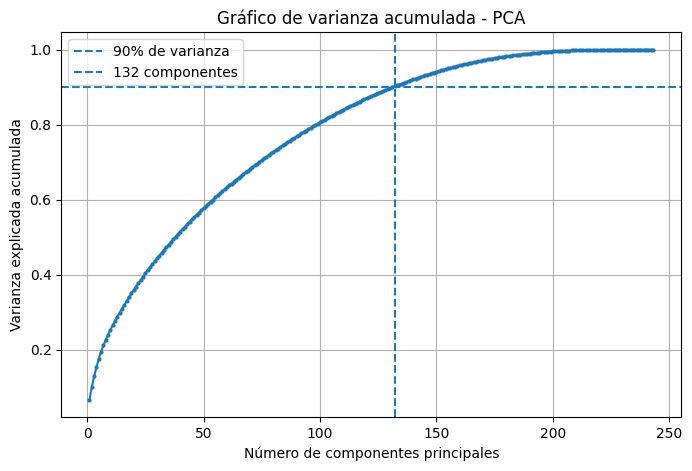

In [ ]:
# Aplicar PCA con todas las componentes para analizar la varianza acumulada

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_sin_pca)

# Calcular varianza explicada acumulada
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

# Seleccionar el número mínimo de componentes que explique al menos el 90% de la varianza
num_componentes = np.argmax(varianza_acumulada >= 0.90) + 1

# Crear la base con PCA
pca = PCA(n_components=num_componentes, random_state=RANDOM_STATE)
X_con_pca = pca.fit_transform(X_sin_pca)

print("Dimensión base sin PCA:", X_sin_pca.shape)
print("Dimensión base con PCA:", X_con_pca.shape)
print("Componentes seleccionados:", num_componentes)
print("Varianza explicada acumulada:", round(pca.explained_variance_ratio_.sum(), 4))

# Gráfico de varianza acumulada
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker="o", markersize=2)
plt.axhline(y=0.90, linestyle="--", label="90% de varianza")
plt.axvline(x=num_componentes, linestyle="--", label=f"{num_componentes} componentes")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("Gráfico de varianza acumulada - PCA")
plt.grid(True)
plt.legend()
plt.show()

**Análisis Punto 2**
- La base sin PCA tiene 243 variables después de One-Hot Encoding y normalización.
- PCA redujo la base a 132 componentes principales.
- Estos componentes explican aproximadamente el 90.1% de la varianza acumulada.
- Con esto se generan dos bases comparables: una con toda la información transformada y otra con dimensionalidad reducida.

---
# Punto 3. Challenge entre algoritmos

Se comparan cinco modelos de clustering, considerando algoritmos basados en distancia y algoritmos basados en densidad. Esto permite evaluar si la estructura de la base House Prices se comporta mejor bajo agrupamientos por cercanía o bajo agrupamientos por concentración de puntos.

In [ ]:
# Modelos seleccionados para el challenge

modelos_challenge = pd.DataFrame({
    "Tipo": [
        "Distancia",
        "Distancia / Jerárquico",
        "Distancia / Jerárquico",
        "Densidad",
        "Densidad"
    ],
    "Algoritmo": [
        "K-Means",
        "Agglomerative Ward",
        "Agglomerative Complete",
        "DBSCAN",
        "OPTICS"
    ]
})

display(modelos_challenge)

,Tipo,Algoritmo
0,Distancia,K-Means
1,Distancia / Jerárquico,Agglomerative Ward
2,Distancia / Jerárquico,Agglomerative Complete
3,Densidad,DBSCAN
4,Densidad,OPTICS


In [ ]:
# Función para evaluar resultados de clustering

def evaluar_resultado(modelo, base, X_base, labels, k=np.nan, eps=np.nan, min_samples=np.nan, xi=np.nan):
    labels = np.array(labels)

    # En DBSCAN y OPTICS, la etiqueta -1 representa ruido
    ruido = np.sum(labels == -1)
    total = len(labels)
    porcentaje_agrupado = round((total - ruido) / total, 4)

    # Cantidad de clusters reales, sin contar ruido
    clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Para calcular métricas se excluye el ruido si existe
    if ruido > 0:
        mask = labels != -1
        X_eval = X_base[mask]
        labels_eval = labels[mask]
    else:
        X_eval = X_base
        labels_eval = labels

    # Validar que existan al menos 2 clusters para calcular métricas
    n_labels = len(np.unique(labels_eval))

    if n_labels >= 2 and n_labels < len(labels_eval):
        sil = silhouette_score(X_eval, labels_eval)
        db = davies_bouldin_score(X_eval, labels_eval)
        ch = calinski_harabasz_score(X_eval, labels_eval)
    else:
        sil = np.nan
        db = np.nan
        ch = np.nan

    return {
        "Base": base,
        "Modelo": modelo,
        "K": k,
        "eps": eps,
        "min_samples": min_samples,
        "xi": xi,
        "Clusters": clusters,
        "Ruido": ruido,
        "Porcentaje_agrupado": porcentaje_agrupado,
        "Silhouette": sil,
        "Davies_Bouldin": db,
        "Calinski_Harabasz": ch
    }

In [ ]:
# Challenge entre algoritmos sobre base sin PCA y con PCA

bases = [
    ("Sin PCA", X_sin_pca),
    ("Con PCA", X_con_pca)
]

resultados = []
K_VALUES = range(2, 11)

for nombre_base, X_base in bases:

    print("Ejecutando modelos sobre base:", nombre_base)

    # 1. K-Means
    for k in K_VALUES:
        modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = modelo.fit_predict(X_base)
        resultados.append(evaluar_resultado("K-Means", nombre_base, X_base, labels, k=k))

    # 2. Agglomerative Ward
    for k in K_VALUES:
        modelo = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels = modelo.fit_predict(X_base)
        resultados.append(evaluar_resultado("Agglomerative Ward", nombre_base, X_base, labels, k=k))

    # 3. Agglomerative Complete
    for k in K_VALUES:
        modelo = AgglomerativeClustering(n_clusters=k, linkage="complete")
        labels = modelo.fit_predict(X_base)
        resultados.append(evaluar_resultado("Agglomerative Complete", nombre_base, X_base, labels, k=k))

    # 4. DBSCAN
    min_samples_dbscan = 5
    vecinos = NearestNeighbors(n_neighbors=min_samples_dbscan)
    vecinos.fit(X_base)
    distancias = vecinos.kneighbors(X_base)[0][:, -1]
    eps_values = np.quantile(distancias, [0.70, 0.80, 0.90, 0.95])
    eps_values = sorted(set(np.round(eps_values, 2)))

    for eps in eps_values:
        modelo = DBSCAN(eps=eps, min_samples=min_samples_dbscan)
        labels = modelo.fit_predict(X_base)
        resultados.append(
            evaluar_resultado("DBSCAN", nombre_base, X_base, labels, eps=eps, min_samples=min_samples_dbscan)
        )

    # 5. OPTICS
    for min_s in [5, 10]:
        modelo = OPTICS(min_samples=min_s, xi=0.05)
        labels = modelo.fit_predict(X_base)
        resultados.append(
            evaluar_resultado("OPTICS", nombre_base, X_base, labels, min_samples=min_s, xi=0.05)
        )

# Crear y ordenar tabla de resultados
resultados_df = pd.DataFrame(resultados)
resultados_ordenados = resultados_df.sort_values(
    by="Silhouette",
    ascending=False,
    na_position="last"
).reset_index(drop=True)

print("Tabla de resultados ordenada por Silhouette:")
display(resultados_ordenados)

Ejecutando modelos sobre base: Sin PCA
Ejecutando modelos sobre base: Con PCA
Tabla de resultados ordenada por Silhouette:


,Base,Modelo,K,eps,min_samples,xi,Clusters,Ruido,Porcentaje_agrupado,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,Con PCA,Agglomerative Complete,2.0,NaN,NaN,NaN,2,0,1.0000,0.676020,0.230181,15.765201
1,Con PCA,Agglomerative Complete,3.0,NaN,NaN,NaN,3,0,1.0000,0.663232,0.236281,15.268442
2,Sin PCA,Agglomerative Complete,2.0,NaN,NaN,NaN,2,0,1.0000,0.660297,0.242321,14.430548
3,Sin PCA,Agglomerative Complete,3.0,NaN,NaN,NaN,3,0,1.0000,0.644536,0.250047,13.862731
4,Sin PCA,Agglomerative Complete,4.0,NaN,NaN,NaN,4,0,1.0000,0.610648,0.264053,12.919777
...,...,...,...,...,...,...,...,...,...,...,...,...
61,Sin PCA,Agglomerative Ward,10.0,NaN,NaN,NaN,10,0,1.0000,-0.013697,2.961625,28.237679
62,Sin PCA,DBSCAN,NaN,19.81,5.0,NaN,1,118,0.9192,NaN,NaN,NaN
63,Sin PCA,DBSCAN,NaN,24.24,5.0,NaN,1,61,0.9582,NaN,NaN,NaN
64,Con PCA,DBSCAN,NaN,18.02,5.0,NaN,1,118,0.9192,NaN,NaN,NaN


### Análisis del Punto 3

En este punto se realizó un *challenge* entre cinco algoritmos de clustering, aplicados sobre dos versiones de la base de datos: una base **sin PCA** y una base **con PCA**. El objetivo fue comparar si la estructura de la base **House Prices** se representa mejor mediante agrupamientos por cercanía entre observaciones o mediante zonas de mayor densidad.

Los algoritmos evaluados fueron **K-Means**, **Agglomerative Ward**, **Agglomerative Complete**, **DBSCAN** y **OPTICS**. Los tres primeros corresponden a métodos basados en distancia o cercanía entre observaciones, mientras que DBSCAN y OPTICS corresponden a métodos basados en densidad.

En el caso de **Agglomerative Clustering**, se evaluaron dos criterios de enlace: **Ward** y **Complete**. Esta decisión permite observar cómo cambia el agrupamiento cuando se modifica la forma de medir la cercanía entre clusters. Ward tiende a formar grupos más compactos, mientras que Complete considera la distancia máxima entre observaciones de distintos grupos, generando una separación más estricta entre clusters.

Los resultados muestran que los mejores desempeños fueron obtenidos por **Agglomerative Complete**, especialmente sobre la base **con PCA**. El mejor resultado corresponde a **Agglomerative Complete con PCA y K = 2**, con un índice de **Silhouette cercano a 0,676**, lo que indica una separación aceptable entre clusters. Además, este modelo no genera ruido, por lo que clasifica el 100% de las viviendas.

En cambio, algunos modelos basados en densidad, como **DBSCAN**, no lograron resultados consistentes en ciertas configuraciones, ya que generaron solo un cluster. Por esta razón, algunas métricas aparecen como `NaN`, debido a que indicadores como Silhouette, Davies-Bouldin y Calinski-Harabasz requieren al menos dos clusters para poder calcularse.

En consecuencia, para esta base de datos, los métodos jerárquicos muestran una mejor capacidad de segmentación que los métodos de densidad. Sin embargo, esta selección debe complementarse en el Punto 4 con el análisis de la variable `SalePrice`, ya que en aprendizaje no supervisado no basta con revisar las métricas internas: también es necesario validar si los clusters tienen una interpretación coherente con el problema analizado.

---
# Punto 4. Evaluación de modelos

Se evalúan los modelos mediante tres métricas internas de clustering:

| Métrica | Interpretación |
|---|---|
| Silhouette | Más alto es mejor. Evalúa cohesión interna y separación entre clusters. |
| Davies-Bouldin | Más bajo es mejor. Evalúa dispersión interna y separación entre clusters. |
| Calinski-Harabasz | Más alto es mejor. Evalúa varianza entre clusters versus varianza interna. |

Se utiliza **Silhouette** como métrica principal porque mide qué tan bien asignada está cada observación a su cluster, considerando tanto la cercanía con su propio grupo como la distancia respecto a otros grupos. Además, se incorporan **Davies-Bouldin** y **Calinski-Harabasz** como métricas complementarias para respaldar la selección del mejor modelo.

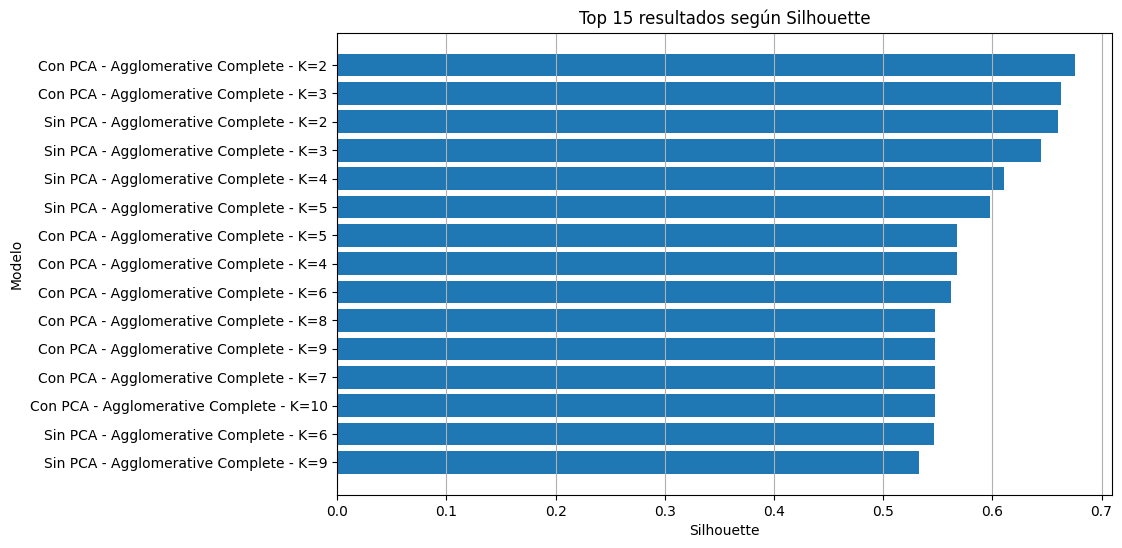

In [ ]:
# Gráfico comparativo de los 15 mejores resultados

top_15 = resultados_ordenados.head(15).copy()

def crear_nombre_modelo(row):
    if pd.notna(row["K"]):
        parametro = "K=" + str(int(row["K"]))
    elif pd.notna(row["eps"]):
        parametro = "eps=" + str(row["eps"])
    else:
        parametro = "min_samples=" + str(int(row["min_samples"]))

    return row["Base"] + " - " + row["Modelo"] + " - " + parametro

top_15["Nombre"] = top_15.apply(crear_nombre_modelo, axis=1)

plt.figure(figsize=(10, 6))
plt.barh(top_15["Nombre"], top_15["Silhouette"])
plt.xlabel("Silhouette")
plt.ylabel("Modelo")
plt.title("Top 15 resultados según Silhouette")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

Interpretación del ranking
- El gráfico ordena los modelos según el índice de Silhouette.
- Un valor mayor indica mejor separación y cohesión de los clusters.
- En modelos de densidad también se debe revisar la cantidad de observaciones clasificadas como ruido.
- Por esta razón, la selección final considera tanto la métrica como la representatividad del modelo.



In [ ]:
# Selección del modelo final

# Mejor modelo solo según Silhouette
mejor_por_silhouette = resultados_ordenados.iloc[0]

print("Mejor resultado según Silhouette:")
display(pd.DataFrame([mejor_por_silhouette]))

# Criterio adicional: evitar modelos que dejan demasiadas observaciones como ruido
# Se exige que al menos el 70% de las observaciones queden agrupadas
candidatos = resultados_ordenados[
    (resultados_ordenados["Silhouette"].notna()) &
    (resultados_ordenados["Clusters"] >= 2) &
    (resultados_ordenados["Porcentaje_agrupado"] >= 0.70)
].copy()

if len(candidatos) > 0:
    mejor_modelo = candidatos.iloc[0]
else:
    mejor_modelo = mejor_por_silhouette

print("Modelo seleccionado considerando métrica e interpretabilidad:")
display(pd.DataFrame([mejor_modelo]))

Mejor resultado según Silhouette:


,Base,Modelo,K,eps,min_samples,xi,Clusters,Ruido,Porcentaje_agrupado,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,Con PCA,Agglomerative Complete,2.0,NaN,NaN,NaN,2,0,1.0,0.67602,0.230181,15.765201


Modelo seleccionado considerando métrica e interpretabilidad:


,Base,Modelo,K,eps,min_samples,xi,Clusters,Ruido,Porcentaje_agrupado,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,Con PCA,Agglomerative Complete,2.0,NaN,NaN,NaN,2,0,1.0,0.67602,0.230181,15.765201


### Interpretación de la selección final

El modelo seleccionado corresponde a **Agglomerative Complete aplicado sobre la base con PCA, utilizando K = 2 clusters**. Este modelo obtuvo el mejor valor de Silhouette entre las alternativas evaluadas, con un resultado de **0,6760**, lo que indica una buena separación matemática entre los grupos.

Además, presenta un índice **Davies-Bouldin de 0,2302**, valor bajo que respalda una baja dispersión interna y una buena separación entre clusters. El índice **Calinski-Harabasz de 15,7652** complementa la evaluación, indicando una relación favorable entre la separación de los clusters y la dispersión interna.

Sin embargo, la selección del modelo no debe interpretarse únicamente desde las métricas internas. Aunque el modelo agrupa el 100% de las viviendas y no genera ruido, el análisis posterior muestra que los clusters no quedan equilibrados en tamaño, ya que la mayoría de las observaciones se concentra en un solo grupo. Por esta razón, el modelo se considera válido para continuar el análisis exploratorio, pero su interpretación práctica debe revisarse junto con `SalePrice` y las características de cada cluster.

## 4.1 Visualización de resultados con K-Means

Aunque el modelo final puede no ser K-Means, se incluye una visualización del mejor K-Means porque ayuda a comprender gráficamente cómo se forman clusters basados en distancia. Para graficar, se proyectan los datos a dos componentes principales.

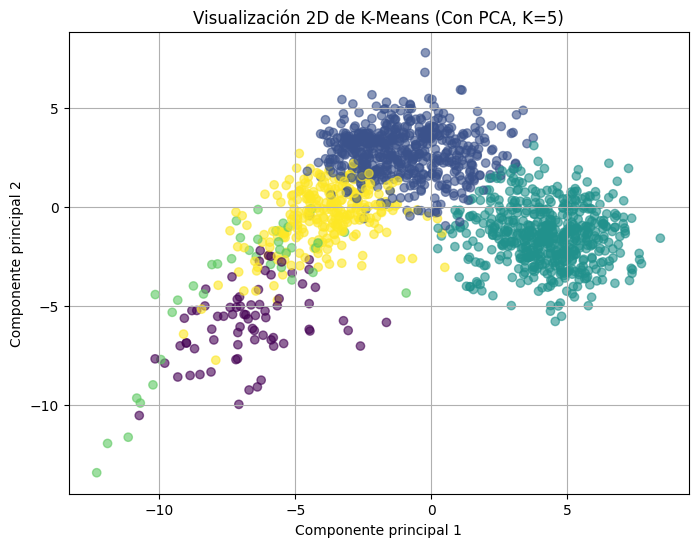

In [ ]:
# Seleccionar el mejor resultado de K-Means

mejor_kmeans = resultados_ordenados[resultados_ordenados["Modelo"] == "K-Means"].iloc[0]

if mejor_kmeans["Base"] == "Sin PCA":
    X_kmeans = X_sin_pca
else:
    X_kmeans = X_con_pca

k_kmeans = int(mejor_kmeans["K"])
modelo_kmeans = KMeans(n_clusters=k_kmeans, random_state=RANDOM_STATE, n_init=10)
labels_kmeans = modelo_kmeans.fit_predict(X_kmeans)

# Proyección a 2 dimensiones para visualizar
pca_vis = PCA(n_components=2, random_state=RANDOM_STATE)
X_kmeans_2d = pca_vis.fit_transform(X_kmeans)

plt.figure(figsize=(8, 6))
plt.scatter(X_kmeans_2d[:, 0], X_kmeans_2d[:, 1], c=labels_kmeans, alpha=0.6)
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title(f"Visualización 2D de K-Means ({mejor_kmeans['Base']}, K={k_kmeans})")
plt.grid(True)
plt.show()

### Interpretación de la visualización 2D de K-Means

La figura muestra una representación bidimensional de los clusters generados por K-Means utilizando la base con PCA y un valor de K = 5. Cada punto representa una vivienda y cada color corresponde a un cluster asignado por el algoritmo.

La visualización permite observar que existen algunas zonas donde los grupos se diferencian visualmente, especialmente en los extremos del gráfico. Sin embargo, también se aprecia superposición entre colores en la zona central, lo que indica que no todos los clusters están completamente separados.

Este resultado sugiere que K-Means logra identificar ciertos patrones en la base House Prices, pero su segmentación no es perfecta. Por esta razón, el gráfico se utiliza como apoyo visual y debe complementarse con las métricas de evaluación, como Silhouette, Davies-Bouldin y Calinski-Harabasz.

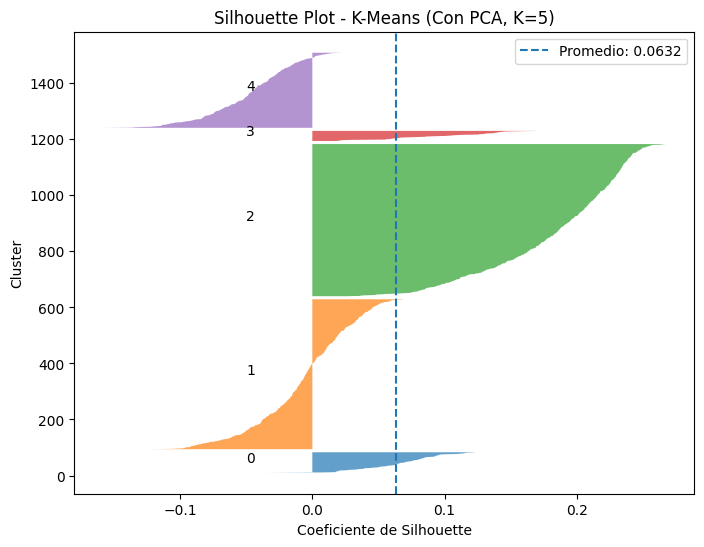

In [ ]:
# Gráfico Silhouette Plot del mejor K-Means

valores_silhouette = silhouette_samples(X_kmeans, labels_kmeans)
silhouette_promedio = silhouette_score(X_kmeans, labels_kmeans)

plt.figure(figsize=(8, 6))
y_lower = 10

for i in range(k_kmeans):
    valores_cluster = valores_silhouette[labels_kmeans == i]
    valores_cluster.sort()
    size_cluster = valores_cluster.shape[0]
    y_upper = y_lower + size_cluster

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        valores_cluster,
        alpha=0.7
    )
    plt.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
    y_lower = y_upper + 10

plt.axvline(x=silhouette_promedio, linestyle="--", label=f"Promedio: {round(silhouette_promedio, 4)}")
plt.xlabel("Coeficiente de Silhouette")
plt.ylabel("Cluster")
plt.title(f"Silhouette Plot - K-Means ({mejor_kmeans['Base']}, K={k_kmeans})")
plt.legend()
plt.show()

### Interpretación del Silhouette Plot de K-Means

El gráfico muestra la calidad de asignación de las observaciones para el modelo K-Means aplicado sobre la base con PCA, utilizando K = 5. Cada color representa un cluster y el eje horizontal muestra el coeficiente de Silhouette de cada vivienda.

El promedio general de Silhouette es 0,0632, lo que indica una estructura de agrupamiento débil. Si bien el modelo logra formar cinco clusters, varios puntos presentan valores cercanos a cero o negativos, lo que evidencia que algunas viviendas no están claramente separadas de otros grupos.

Por lo tanto, este resultado sugiere que K-Means con K = 5 no entrega una segmentación suficientemente robusta para esta base. El gráfico se utiliza como apoyo visual para comprender la calidad del agrupamiento, pero la selección final del modelo debe realizarse considerando todas las métricas de evaluación y la interpretación posterior respecto a `SalePrice`.

## 4.2 Análisis del modelo seleccionado respecto a `SalePrice`

Una vez seleccionado el modelo final, se vuelve a incorporar la variable `SalePrice`, pero solo para interpretar los clusters. Esta variable no fue utilizada durante el entrenamiento, por lo que su análisis permite revisar si los grupos encontrados diferencian viviendas de distinto nivel de precio.

In [ ]:
# Reconstruir el modelo seleccionado

base_final = mejor_modelo["Base"]
modelo_final_nombre = mejor_modelo["Modelo"]

if base_final == "Sin PCA":
    X_final = X_sin_pca
else:
    X_final = X_con_pca

if modelo_final_nombre == "K-Means":
    modelo_final = KMeans(
        n_clusters=int(mejor_modelo["K"]),
        random_state=RANDOM_STATE,
        n_init=10
    )
    labels_final = modelo_final.fit_predict(X_final)

elif modelo_final_nombre == "Agglomerative Ward":
    modelo_final = AgglomerativeClustering(
        n_clusters=int(mejor_modelo["K"]),
        linkage="ward"
    )
    labels_final = modelo_final.fit_predict(X_final)

elif modelo_final_nombre == "Agglomerative Complete":
    modelo_final = AgglomerativeClustering(
        n_clusters=int(mejor_modelo["K"]),
        linkage="complete"
    )
    labels_final = modelo_final.fit_predict(X_final)

elif modelo_final_nombre == "DBSCAN":
    modelo_final = DBSCAN(
        eps=float(mejor_modelo["eps"]),
        min_samples=int(mejor_modelo["min_samples"])
    )
    labels_final = modelo_final.fit_predict(X_final)

elif modelo_final_nombre == "OPTICS":
    modelo_final = OPTICS(
        min_samples=int(mejor_modelo["min_samples"]),
        xi=float(mejor_modelo["xi"])
    )
    labels_final = modelo_final.fit_predict(X_final)

# Crear base con clusters para interpretación
df_cluster = df_limpia.copy()
df_cluster["cluster"] = labels_final

print("Clusters generados por el modelo final:")
print(pd.Series(labels_final).value_counts().sort_index())

Clusters generados por el modelo final:
0    1459
1       1
Name: count, dtype: int64


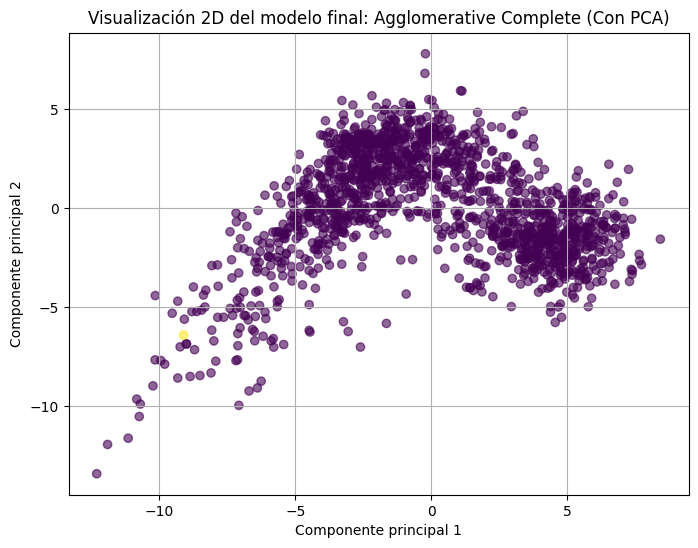

In [ ]:
# Visualización 2D del modelo final

pca_final_vis = PCA(n_components=2, random_state=RANDOM_STATE)
X_final_2d = pca_final_vis.fit_transform(X_final)

plt.figure(figsize=(8, 6))
plt.scatter(X_final_2d[:, 0], X_final_2d[:, 1], c=labels_final, alpha=0.6)
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title(f"Visualización 2D del modelo final: {modelo_final_nombre} ({base_final})")
plt.grid(True)
plt.show()

### Interpretación de la visualización 2D del modelo final

La figura muestra la visualización bidimensional del modelo final seleccionado: **Agglomerative Complete aplicado sobre la base con PCA**. Cada punto representa una vivienda y el color indica el cluster asignado por el algoritmo.

Se observa que el modelo separa la base en dos grupos. La mayoría de las viviendas se concentra en un cluster principal, mientras que un grupo reducido queda separado del resto. Esta separación visual es coherente con el valor de Silhouette obtenido, ya que el modelo logra identificar observaciones que presentan características diferentes al conjunto principal.

Sin embargo, la visualización también muestra que los clusters no son equilibrados en tamaño. Por lo tanto, el resultado debe interpretarse como una segmentación que distingue principalmente viviendas con características más diferenciadas o extremas, más que como una división homogénea de todo el mercado de viviendas.

In [ ]:
# Precio de venta por cluster

precio_por_cluster = (
    df_cluster
    .groupby("cluster")[TARGET]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
    .sort_values(by="mean")
)

print("Resumen de SalePrice por cluster:")
display(precio_por_cluster)

Resumen de SalePrice por cluster:


,count,mean,median,min,max
cluster,,,,,
1,1,67000.00,67000.0,67000.00,67000.00
0,1459,180003.82,163000.0,61815.97,442567.01


<Figure size 800x500 with 0 Axes>

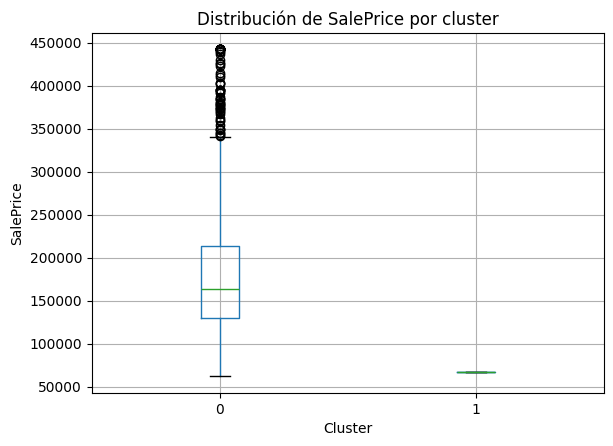

In [ ]:
# Boxplot de SalePrice por cluster

plt.figure(figsize=(8, 5))
df_cluster.boxplot(column=TARGET, by="cluster")
plt.title("Distribución de SalePrice por cluster")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("SalePrice")
plt.show()

### Interpretación del boxplot de SalePrice por cluster

El boxplot muestra la distribución del precio de venta (`SalePrice`) para cada cluster generado por el modelo final. Esta visualización permite revisar si los grupos obtenidos por el algoritmo presentan diferencias respecto a la variable objetivo que fue excluida del entrenamiento.

Se observa que el **cluster 0** concentra la mayor parte de las viviendas y presenta una amplia dispersión de precios, incluyendo viviendas de valor medio y alto. En cambio, el **cluster 1** agrupa un número reducido de viviendas con precios bajos y poca variabilidad interna.

Esto indica que el modelo logra identificar un grupo pequeño de viviendas con características y precios diferentes al conjunto principal. Sin embargo, la segmentación no es equilibrada, ya que la mayoría de las observaciones queda concentrada en un solo cluster. Por lo tanto, el modelo permite distinguir ciertos casos específicos, pero no divide la base en segmentos de tamaño similar.

In [ ]:
# Características numéricas principales por cluster

variables_interpretacion = [
    "OverallQual", "GrLivArea", "GarageCars",
    "TotalBsmtSF", "YearBuilt", "FullBath", "LotArea"
]

variables_disponibles = [col for col in variables_interpretacion if col in df_cluster.columns]

caracteristicas_cluster = (
    df_cluster
    .groupby("cluster")[variables_disponibles]
    .mean()
    .round(2)
)

print("Promedio de características principales por cluster:")
display(caracteristicas_cluster)

Promedio de características principales por cluster:


,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,LotArea
cluster,,,,,,,
0,6.1,1510.59,1.76,1050.67,1971.45,1.57,10063.76
1,5.0,1077.00,1.00,961.00,1920.00,1.00,8967.00


### Interpretación de las características por cluster

La tabla permite analizar qué características tienen en común las viviendas agrupadas por el modelo final. Se observa que el **cluster 0** concentra prácticamente la totalidad de las viviendas y presenta valores promedio superiores en variables como `OverallQual`, `GrLivArea`, `GarageCars`, `TotalBsmtSF`, `FullBath` y `LotArea`. Además, tiene un año promedio de construcción más reciente.

Por otro lado, el **cluster 1** contiene solo una vivienda, por lo que sus valores no deben interpretarse como un segmento representativo del mercado. Aun así, esta observación presenta características inferiores al promedio del cluster principal: menor calidad general, menor superficie habitable, menor capacidad de garaje, menor cantidad de baños y mayor antigüedad.

Por lo tanto, el análisis de características permite observar que el modelo separó una vivienda con características distintas respecto al conjunto principal. Sin embargo, debido a que el cluster 1 tiene solo una observación, el resultado debe interpretarse como una detección de un caso atípico o muy diferenciado, más que como una segmentación equilibrada de viviendas.

### Interpretación final del Punto 4

El modelo seleccionado fue **Agglomerative Complete aplicado sobre la base con PCA**, utilizando **K = 2 clusters**. Este modelo obtuvo el mejor valor de Silhouette (**0,6760**) y un índice Davies-Bouldin bajo (**0,2302**), lo que indica una buena separación matemática entre los grupos.

Sin embargo, al analizar la distribución de observaciones por cluster, se observa que el modelo genera un cluster principal con **1459 viviendas** y un segundo cluster con solo **1 vivienda**. Por lo tanto, aunque las métricas internas son favorables, la segmentación no es equilibrada desde el punto de vista práctico.

Al reincorporar `SalePrice`, se observa que el cluster minoritario corresponde a una vivienda de bajo precio y características distintas al conjunto principal. En consecuencia, el modelo logra identificar una observación atípica o muy diferenciada, pero no divide la base en segmentos homogéneos y representativos del mercado.

Por lo tanto, el resultado debe interpretarse como una segmentación exploratoria. El modelo presenta buen desempeño métrico, pero su utilidad práctica es limitada porque concentra casi todas las viviendas en un solo cluster.

---
# Punto 5. Carga del cuaderno en GitHub

Para cumplir con la entrega del cuaderno Python en GitHub, se deben ejecutar comandos similares a los siguientes desde el entorno local o desde la terminal conectada al repositorio del grupo:

```bash
git add Trabajo_Unidad_3_ML.ipynb
git commit -m "Trabajo Unidad 3 Machine Learning"
git push origin main
```

Estos comandos permiten agregar el archivo al repositorio, registrar los cambios mediante un commit y cargar la versión final en GitHub.

---
## Conclusión

En este trabajo se aplicaron algoritmos de aprendizaje no supervisado sobre la base **House Prices**, manteniendo continuidad metodológica con las unidades anteriores. Primero, se separó la variable `SalePrice`, ya que en clustering no debe utilizarse como variable de entrenamiento. Posteriormente, se preparó la base mediante tratamiento de valores faltantes, transformación de variables categóricas con **One-Hot Encoding** y normalización de las variables, debido a que los algoritmos basados en distancia y densidad requieren trabajar con datos numéricos y comparables en una escala común.

Luego, se construyeron dos bases de análisis: una **sin PCA** y otra **con PCA**. La aplicación de PCA permitió reducir la dimensionalidad del conjunto de datos, conservando aproximadamente el **90% de la varianza explicada**. Esta comparación permitió evaluar si los algoritmos obtenían mejores resultados trabajando con todas las variables transformadas o con una representación más compacta de la información.

En el challenge se evaluaron cinco modelos de clustering: **K-Means**, **Agglomerative Ward**, **Agglomerative Complete**, **DBSCAN** y **OPTICS**, incorporando algoritmos basados en distancia, jerárquicos y de densidad. La evaluación se realizó mediante tres métricas internas: **Silhouette**, **Davies-Bouldin** y **Calinski-Harabasz**. El mejor resultado fue obtenido por **Agglomerative Complete aplicado sobre la base con PCA, con K = 2**, alcanzando un **Silhouette de 0,6760** y un **Davies-Bouldin de 0,2302**, lo que indica una separación adecuada entre los clusters desde el punto de vista métrico.

Sin embargo, el análisis posterior mostró que el modelo seleccionado generó una segmentación poco equilibrada, concentrando la gran mayoría de las viviendas en un cluster principal y dejando un segundo cluster con muy pocas observaciones. Esto demuestra que, en aprendizaje no supervisado, no basta con seleccionar un modelo solo por sus métricas internas; también es necesario revisar la representatividad e interpretabilidad de los grupos obtenidos.

Finalmente, al reincorporar `SalePrice` solo para interpretación, se observó que los clusters presentan diferencias en precio y en variables relevantes como calidad general, superficie habitable, capacidad de garaje, baños y año de construcción. Por lo tanto, el modelo permitió identificar diferencias relevantes dentro de la base, pero su resultado debe entenderse como una segmentación exploratoria y no como una clasificación definitiva del mercado de viviendas.

---
# Bibliografía

- Universidad Mayor. (2026). *Unidad 3: Algoritmos no-supervisados*. Material de clase de Machine Learning.
- Universidad Mayor. (2026). *Ficha de Actividad: Machine Learning, Unidad 3*. Escuela de Ingeniería.
- Ester, M., Kriegel, H. P., Sander, J., & Xu, X. (1996). *A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise*. Proceedings of KDD.
- Ankerst, M., Breunig, M. M., Kriegel, H. P., & Sander, J. (1999). *OPTICS: Ordering Points To Identify the Clustering Structure*. ACM SIGMOD.
- Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: a review and recent developments. *Philosophical Transactions of the Royal Society A*.
- Scikit-learn. (s. f.). *Clustering and decomposition modules documentation*.
- Kaggle. (s. f.). *House Prices - Advanced Regression Techniques*. Kaggle Competition Dataset.